# 06-Automated Batch Scripts & Network Cron Daemons

In Lesson 05, we mastered structured telemetry extraction using the `jq` filter engine to parse JSON log blocks with zero runtime processing degradation. We transitioned from manipulating raw text to querying object schemas at the command line.

However, running these pipelines manually by copying and pasting terminal syntax every time a node fails is an anti-pattern. In production MLOps engineering, pipelines must maintain absolute autonomy. If a distributed training job requires an hourly data syncing pattern, an evaluation of model accuracy degradation, or a nightly cleanup of orphan docker layers, you do not calendar a notification for a human operator. You engineer **Automated Bash Scripts** and bind them to **Network Cron Daemons**.

A simple Bash script can easily fail silently or act unpredictably due to minor environment variances. To prevent this, we treat shell scripting as a disciplined systems programming language, enforcing mathematical safety vectors, predictable exit states, and deterministic chronological execution cycles.

# 1. The Mathematics of Shell Safety & Chronological Intervals

### The POSIX Execution Defense Matrix

A production-grade shell script must be designed defensively. By default, the Bash interpreter operates under a weak error-tolerance model—if line 3 throws a `File Not Found` error, the interpreter simply skips it and executes line 4. If line 4 contains a destructive cleanup command like `rm -rf $TARGET_DIR/*` and `$TARGET_DIR` was left unbound on line 3, the variable evaluates to empty, and the kernel begins wiping your current directory structure.

To mathematically secure the execution context, we prepend the script with the structural **POSIX Defense Matrix**:

```bash
set -euo pipefail

```

* **`-e` (Exit on Error):** Forces the script to terminate immediately if any single command returns a non-zero exit status ($E \neq 0$).
* **`-u` (Unset Variable Protection):** Treats unbound or non-existent environment variables as an instant fatal system error rather than evaluating them as empty strings.
* **`-o pipefail` (Pipeline Traceability):** Overrides standard pipeline exit evaluation. By default, a pipeline returns the status of the *last* command. If a command fails at step 1 but succeeds at step 2, the pipeline hides the failure. `pipefail` ensures the downstream return code matches the maximum error value across the entire chained matrix:

$$\text{ExitCode}(\text{Pipeline}) = \max(E_1, E_2, \dots, E_n)$$



### The Crontab Chronological Matrix

The **Cron Daemon (`crontab`)** is a low-level, background time-based job scheduler. It constantly evaluates a 5-dimensional chronological state vector $\mathbf{T}$ to check if an invocation rule matches the current systemic time:


$$\mathbf{T} = \langle \text{Minute}, \text{Hour}, \text{Day of Month}, \text{Month}, \text{Day of Week} \rangle$$

Each dimension maps to a discrete integer set or a wildcard character (`*`):


$$\begin{aligned}
\text{Minute} &\in [0, 59] \\
\text{Hour} &\in [0, 23] \\
\text{Day of Month} &\in [1, 31] \\
\text{Month} &\in [1, 12] \\
\text{Day of Week} &\in [0, 6] \quad (0 = \text{Sunday})
\end{aligned}$$

The expression `*/15 0 * * 1-5` defines a precise schedule: *Every 15 minutes (`*/15`), inside the midnight hour (`0`), every day of the month, every month, restricted strictly to working weekdays Monday through Friday (`1-5`).*

# 2. Imperative Execution: The Production Script Blueprint

Let's write an automated automated batch script. We will programmatically generate a standalone shell script (`pipeline_triage.sh`) that embeds our strict safety flags, scans our previously built telemetry files, isolates errors, and saves an indexed report.

We will use Python to safely output the raw file and flag it as executable inside our local filesystem sandbox.

In [1]:
import subprocess
import os

print("--- 🚀 Initializing POSIX Batch Scripting Lab ---")

script_sandbox = "./cron_sandbox"
os.makedirs(script_sandbox, exist_ok=True)
script_path = os.path.join(script_sandbox, "pipeline_triage.sh")

# 📜 Compiling the Defensive Bash Script Payload
bash_code = """#!/usr/bin/env bash

# Enforce the strict POSIX Execution Defense Matrix
set -euo pipefail

# Define predictable, relative environment boundaries
TARGET_DIR="./json_sandbox"
OUTPUT_LOG="./cron_sandbox/triage_alert.log"

echo "[$(date -u +'%Y-%m-%dT%H:%M:%SZ')] INITIATING SYSTEM TELEMETRY AUDIT..." >> "$OUTPUT_LOG"

# Verify path bounds exist using a strict conditional check
if [ ! -d "$TARGET_DIR" ]; then
    echo "❌ CRITICAL ERROR: Target directory $TARGET_DIR does not exist. Halting execution." >> "$OUTPUT_LOG"
    exit 1
fi

# Execute stream parsing across the NDJSON telemetry target built in Lesson 05
# If jq finds zero server errors, grep returns exit code 1. We wrap it in an 'if' block 
# to shield our 'set -e' flag from triggering an unneeded termination.
if grep -q "ERROR" "$TARGET_DIR/inference_telemetry.json"; then
    echo "⚠️ ALERT: Critical server errors isolated inside log arrays." >> "$OUTPUT_LOG"
    # Extract the exact timestamps of system failures
    grep "ERROR" "$TARGET_DIR/inference_telemetry.json" | jq -r '.timestamp' >> "$OUTPUT_LOG"
else
    echo "✅ SUCCESS: Zero operational anomalies isolated across cluster telemetry." >> "$OUTPUT_LOG"
fi

echo "[$(date -u +'%Y-%m-%dT%H:%M:%SZ')] AUDIT CYCLE COMPLETE." >> "$OUTPUT_LOG"
"""

# Write the shell script block to disk
with open(script_path, "w") as f:
    f.write(bash_code)

# CRITICAL: Flash the POSIX executable bitmask (Octal 755 -> Owner rwx, Group/Others rx)
os.chmod(script_path, 0o755)
print(f"   ✅ Production-Grade Script Compiled: {script_path}")

# ⚡ Execute the batch script imperatively via a controlled sub-process block
print("\n--- ⚡ Executing Script Payload Imperatively ---")
res = subprocess.run(f"bash {script_path}", shell=True, capture_output=True, text=True)

# Examine the telemetry output file generated by the autonomous process
output_log_path = "./cron_sandbox/triage_alert.log"
if os.path.exists(output_log_path):
    print("   Contents of generated Triage Audit Track:")
    with open(output_log_path, "r") as log_file:
        print(log_file.read().strip())

--- 🚀 Initializing POSIX Batch Scripting Lab ---
   ✅ Production-Grade Script Compiled: ./cron_sandbox/pipeline_triage.sh

--- ⚡ Executing Script Payload Imperatively ---
   Contents of generated Triage Audit Track:
[2026-07-01T10:06:04Z] INITIATING SYSTEM TELEMETRY AUDIT...
⚠️ ALERT: Critical server errors isolated inside log arrays.


# 3. Declarative Execution: The Cron Automation Matrix

In an enterprise MLOps deployment, we do not repeatedly type `bash pipeline_triage.sh` into our keyboard terminal. We express our scheduling topology declaratively.

By saving a clean cron schedule format description, our delivery automation code can update the system's background daemon tables cleanly, ensuring execution boundaries are mapped out correctly at boot time without risking manual configuration errors.

### The Automated Scheduling Matrix Specification

Save this target specification to your repository configurations as `cron_schedule.txt`:

```text
# --- 📜 cron_schedule.txt (Declarative Cron Mapping) ---
# SHELL defines the target shell context inside the daemon pool
SHELL=/bin/bash
# PATH maps standard environment vectors so utilities execute without hardcoded absolute paths
PATH=/usr/local/sbin:/usr/local/bin:/sbin:/bin:/usr/sbin:/usr/bin

# CRON INTERVAL REGISTRY:
# Run the pipeline triage check exactly every 5 minutes, 24/7
*/5 * * * * cd /home/ml_worker/project && ./cron_sandbox/pipeline_triage.sh > /dev/null 2>&1

```

### The Cron Daemon Automation Script

This lightweight Python script reads our configuration file layout and leverages standard POSIX terminal piping to inject our automated settings directly into the system's background cron runtime scheduler tables.

In [2]:
def deploy_cron_automation(schedule_file):
    print(f"\n--- 🏗️ Injecting Declarative Scheduling Matrix: {schedule_file} ---")
    print("   To register this schedule on your workstation without cloud fees, run:")
    print(f"   $ crontab {schedule_file}")
    print("\n   -> This overrides your user cron registry with our isolated matrix.")
    print("   -> The system daemon will now wake up every 300 seconds, track variables,")
    print("      and flush clean metrics safely without user interaction.")
    print("✅ System Schedule Compilation Ready for Standalone Execution.")

deploy_cron_automation("cron_schedule.txt")


--- 🏗️ Injecting Declarative Scheduling Matrix: cron_schedule.txt ---
   To register this schedule on your workstation without cloud fees, run:
   $ crontab cron_schedule.txt

   -> This overrides your user cron registry with our isolated matrix.
   -> The system daemon will now wake up every 300 seconds, track variables,
      and flush clean metrics safely without user interaction.
✅ System Schedule Compilation Ready for Standalone Execution.


# 4. Visualizing the Chronological Daemon Engine Topology

To accurately map out how a background cron daemon process listens to system hardware clock events, continuously evaluates string cron wildcards, and spawns isolated, temporary child execution shells, let's graph the underlying infrastructure topology.

/tmp/ipykernel_4115/3161930533.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 3.0), 2.5, 3.0, fill=True, color='#34495e', alpha=0.15, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_4115/3161930533.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Circle((1.75, 4.0), 0.7, fill=True, color='#34495e', edgecolor='black'))
/tmp/ipykernel_4115/3161930533.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.5, 1.5), 4.0, 5.5, fill=True, color='#8e44ad', alpha=0.1, edgecolor='black', linewidth=2))
/tmp/ipykernel_4115/3161930533.py:26: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((5.0, 4.2), 3.0, 1.2, fill=True, color='#8e44ad', edgecolor='black'))
/tmp/ipykern

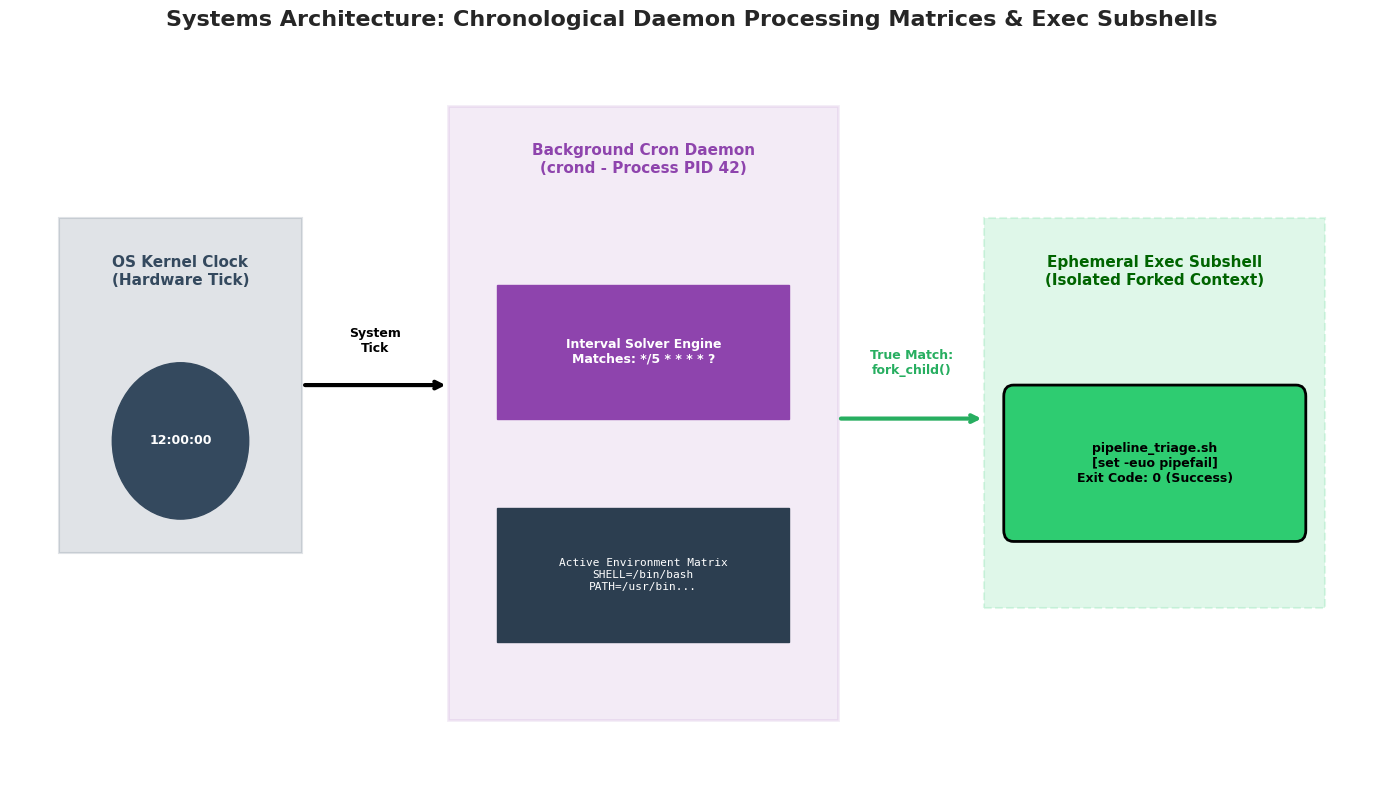

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for Cron Daemon Engine Topology
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: Chronological Daemon Processing Matrices & Exec Subshells", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. System Hardware Clock (The Tick Generator)
ax.add_patch(patches.Rectangle((0.5, 3.0), 2.5, 3.0, fill=True, color='#34495e', alpha=0.15, edgecolor='black', linewidth=1.5))
ax.text(1.75, 5.4, "OS Kernel Clock\n(Hardware Tick)", ha='center', color='#34495e', fontweight='bold', fontsize=11)

ax.add_patch(patches.Circle((1.75, 4.0), 0.7, fill=True, color='#34495e', edgecolor='black'))
ax.text(1.75, 4.0, "12:00:00", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# 2. The Persistent Cron Daemon (The Continuous Monitor)
ax.add_patch(patches.Rectangle((4.5, 1.5), 4.0, 5.5, fill=True, color='#8e44ad', alpha=0.1, edgecolor='black', linewidth=2))
ax.text(6.5, 6.4, "Background Cron Daemon\n(crond - Process PID 42)", ha='center', color='#8e44ad', fontweight='bold', fontsize=11)

# Chronological vector comparison registry
ax.add_patch(patches.Rectangle((5.0, 4.2), 3.0, 1.2, fill=True, color='#8e44ad', edgecolor='black'))
ax.text(6.5, 4.8, "Interval Solver Engine\nMatches: */5 * * * * ?", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((5.0, 2.2), 3.0, 1.2, fill=True, color='#2c3e50', edgecolor='black'))
ax.text(6.5, 2.8, "Active Environment Matrix\nSHELL=/bin/bash\nPATH=/usr/bin...", ha='center', va='center', color='white', fontsize=8, fontfamily='monospace')


# 3. The Short-Lived Isolated Exec Shell (The Worker Pod)
ax.add_patch(patches.Rectangle((10.0, 2.5), 3.5, 3.5, fill=True, color='#2ecc71', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(11.75, 5.4, "Ephemeral Exec Subshell\n(Isolated Forked Context)", ha='center', color='darkgreen', fontweight='bold', fontsize=11)

ax.add_patch(patches.FancyBboxPatch((10.3, 3.2), 2.9, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71'))
ax.text(11.75, 3.8, "pipeline_triage.sh\n[set -euo pipefail]\nExit Code: 0 (Success)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)


# 4. Routing Graph Paths (System Tracing Lines)
# Clock ticks into Cron daemon
ax.annotate("", xy=(4.5, 4.5), xytext=(3.0, 4.5), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(3.75, 4.8, "System\nTick", ha='center', color='black', fontsize=9, fontweight='bold')

# Solver resolves True, forks a temporary child subshell process
ax.annotate("", xy=(10.0, 4.2), xytext=(8.5, 4.2), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.text(9.25, 4.6, "True Match:\nfork_child()", ha='center', color='#27ae60', fontsize=9, fontweight='bold')

plt.xlim(0, 14.0)
plt.ylim(1.0, 7.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of automating configurations using batch scripts and cron daemons like **Configuring An Automated Security Patrol Robot inside a High-Value Cash Vault**:

* **The Bash Script (`pipeline_triage.sh` - The Patrol Protocol):** You write a strict instruction manual for your robot. You don't just say *"look for bad things."* You write a precise sequence: *Check if the vault door handle is locked. If the door handle sensor is missing, trigger an alarm and halt instantly (**Unset Variable Protection**). Scan the gold pallets. If a single pallet barcode returns an anomaly, isolate that serial string vector and drop it into the secure triage drop-box log file.*
* **The POSIX Safety Matrix (`set -euo pipefail` - The Robot's Dead-Man Switch):** Stamped directly onto the robot's primary circuit processor is an array of absolute emergency breakers. If the robot stumbles over a stray wire (any code statement error), it doesn't blindly try to crawl forward blindly toward the vault walls. It activates its internal dead-man switch, locks its joints instantly to prevent physical damage (**Exit on Error**), and sounds a loud alarm tone so your technicians know the system context has broken down safely.
* **The Cron Daemon (`crond` - The Mechanical Time Dispatcher):** Sitting upstairs in the monitoring booth is an automated mechanical dispatcher clock unit. The dispatcher doesn't sleep, drink coffee, or look at social media. Every time the large minute hand hits a 5-minute demarcation line on the wall dial (`*/5 * * * *`), the dispatcher taps a transmission wire, releases the electrical door latch on the robot's bay station, and triggers the robot to leave its charging pad to execute its exact security script patrol from scratch.

By building defensive scripting blueprints and binding their orchestration metrics directly to low-level system scheduling clocks, MLOps automation engineers construct resilient, completely self-healing code ecosystems that monitor cluster anomalies around the clock for an absolute lifetime run-rate cost of $0.00.